In [19]:
import torch, sys, os

print("Python:", sys.version)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
CUDA available: True
GPU: Tesla T4


In [20]:
%cd /kaggle/working

!git clone https://github.com/QuIIL/ICCV2025_Ano-NAViLa.git

/kaggle/working
fatal: destination path 'ICCV2025_Ano-NAViLa' already exists and is not an empty directory.


In [21]:
!apt-get update -qq
!apt-get install -y openslide-tools
!pip install -q openslide-python

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide0 openslide-tools
0 upgraded, 2 newly installed, 0 to remove and 146 not upgraded.
Need to get 104 kB of archives.
After this operation, 297 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 openslide-tools amd64 3.4.1+dfsg-5build1 [13.8 kB]
Fetched 104 kB in 0s (2,185 kB/s)           
Selecting previously unselected package libopenslide0.
(Reading database ... 125128 files and directo

In [22]:
%cd /kaggle/working

!git clone https://github.com/mahmoodlab/CONCH.git
%cd /kaggle/working/CONCH
!pip install -e .

/kaggle/working
Cloning into 'CONCH'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 102 (delta 47), reused 31 (delta 31), pack-reused 36 (from 1)
Receiving objects: 100% (102/102), 1.23 MiB | 26.74 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/kaggle/working/CONCH
Obtaining file:///kaggle/working/CONCH
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
  Building editable for conch (pyproject.toml) ... done
  Created wheel for conch: filename=conch-0.1.0-0.editable-py3-none-any.whl size=19019 sha256=e3bbff02fdfd29e4c2da5dc170005c30d1228ca3b54ff418906d6e6b16f6

In [23]:
import sys
sys.path.insert(0, "/kaggle/working/CONCH")

import torch
import numpy as np
import pandas as pd
import openslide
import conch

print("imports ok")
print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

imports ok
torch: 2.10.0+cu128
numpy: 2.4.6
pandas: 2.3.3


In [24]:
%cd /kaggle/working

!pip install -q gdown
!gdown --id 141a-w_ungtVT9e5vTszAvRonCQEGURSf -O /kaggle/working/re-trained_AnoNAViLa_Model.pth

!ls -lh /kaggle/working/re-trained_AnoNAViLa_Model.pth

/kaggle/working
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=141a-w_ungtVT9e5vTszAvRonCQEGURSf
From (redirected): https://drive.google.com/uc?id=141a-w_ungtVT9e5vTszAvRonCQEGURSf&confirm=t&uuid=3d3e7f01-aba2-46ac-a86f-e6c4bc15773f
To: /kaggle/working/re-trained_AnoNAViLa_Model.pth
100%|██████████████████████████████████████| 1.58G/1.58G [00:22<00:00, 71.0MB/s]
-rw-r--r-- 1 root root 1.5G Oct 17  2025 /kaggle/working/re-trained_AnoNAViLa_Model.pth


In [25]:
%cd /kaggle/working

!wget -O /kaggle/working/test_001.tif "https://s3.ap-northeast-1.wasabisys.com/gigadb-datasets/live/pub/10.5524/100001_101000/100439/CAMELYON16/testing/images/test_001.tif"

!ls -lh /kaggle/working/test_001.tif

/kaggle/working
--2026-06-01 12:02:43--  https://s3.ap-northeast-1.wasabisys.com/gigadb-datasets/live/pub/10.5524/100001_101000/100439/CAMELYON16/testing/images/test_001.tif
Resolving s3.ap-northeast-1.wasabisys.com (s3.ap-northeast-1.wasabisys.com)... 103.151.85.100, 103.151.85.101, 103.151.85.105, ...
Connecting to s3.ap-northeast-1.wasabisys.com (s3.ap-northeast-1.wasabisys.com)|103.151.85.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1142160268 (1.1G) [image/tiff]
Saving to: ‘/kaggle/working/test_001.tif’

/kaggle/working/tes 100%[===================>]   1.06G  2.59MB/s    in 18m 42s 

2026-06-01 12:21:28 (994 KB/s) - ‘/kaggle/working/test_001.tif’ saved [1142160268/1142160268]

-rw-r--r-- 1 root root 1.1G Jul  1  2023 /kaggle/working/test_001.tif


In [27]:
from huggingface_hub import login, hf_hub_download

HF_TOKEN = "MY TOKEN WAS HERE!"

login(token=HF_TOKEN)

path = hf_hub_download(
    repo_id="MahmoodLab/CONCH",
    filename="pytorch_model.bin",
    token=HF_TOKEN,
    local_dir="/kaggle/working/conch_checkpoint",
    local_dir_use_symlinks=False
)

print(path)

/kaggle/working/conch_checkpoint/pytorch_model.bin


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [32]:
from pathlib import Path

backbone_path = Path("/kaggle/working/ICCV2025_Ano-NAViLa/models/backbone.py")

txt = backbone_path.read_text()

old = """CONCH_model, CONCH_preprocess = create_model_from_pretrained('conch_ViT-B-16', "hf_hub:MahmoodLab/conch", hf_auth_token=args["hf_auth_token"])"""

new = """CONCH_model, CONCH_preprocess = create_model_from_pretrained('conch_ViT-B-16', "/kaggle/working/conch_checkpoint/pytorch_model.bin")"""

txt = txt.replace(old, new)

backbone_path.write_text(txt)

print("patched")

patched


In [33]:
!grep -n "create_model_from_pretrained" /kaggle/working/ICCV2025_Ano-NAViLa/models/backbone.py

5:from conch.open_clip_custom import create_model_from_pretrained, tokenize, get_tokenizer
23:    CONCH_model, CONCH_preprocess = create_model_from_pretrained('conch_ViT-B-16', "/kaggle/working/conch_checkpoint/pytorch_model.bin")


In [35]:
import json
from pathlib import Path

repo = Path("/kaggle/working/ICCV2025_Ano-NAViLa")
cfg_path = repo / "configs" / "Ano-NAViLa_lymphnode.json"

with open(cfg_path) as f:
    cfg = json.load(f)

cfg["train"] = 0
cfg["update_centroids"] = 0
cfg["test"] = 1
cfg["WSI_level"] = 0

cfg["test_patches_WSIs_path"] = "/kaggle/working/test_patches"
cfg["test_batch_size"] = 100
cfg["trained_model_pth"] = "/kaggle/working/re-trained_AnoNAViLa_Model.pth"

out_path = repo / "configs" / "inference_test001.json"

with open(out_path, "w") as f:
    json.dump(cfg, f, indent=4)

print(out_path)

/kaggle/working/ICCV2025_Ano-NAViLa/configs/inference_test001.json


In [50]:
import os
import openslide
import numpy as np
from PIL import Image
from tqdm import tqdm

WSI_PATH = "/kaggle/working/test_001.tif"
WSI_ID = "test_001"

PATCH_ROOT = "/kaggle/working/test_patches"
PATCH_DIR = f"{PATCH_ROOT}/{WSI_ID}"
os.makedirs(PATCH_DIR, exist_ok=True)

slide = openslide.OpenSlide(WSI_PATH)
W, H = slide.dimensions

print("WSI dimensions:", W, H)
print("levels:", slide.level_dimensions)

PATCH_READ_SIZE = 256
PATCH_SAVE_SIZE = 256
STRIDE = 256
MAX_PATCHES = None

def is_tissue(pil_img, white_threshold=220, tissue_fraction_threshold=0.45):
    arr = np.array(pil_img.convert("RGB"))
    tissue = np.mean(arr, axis=2) < white_threshold
    return tissue.mean() > tissue_fraction_threshold

count = 0

for y in tqdm(range(0, H - PATCH_READ_SIZE, STRIDE)):
    for x in range(0, W - PATCH_READ_SIZE, STRIDE):
        patch = slide.read_region((x, y), 0, (PATCH_READ_SIZE, PATCH_READ_SIZE)).convert("RGB")

        if not is_tissue(patch):
            continue

        patch = patch.resize((PATCH_SAVE_SIZE, PATCH_SAVE_SIZE))
        patch.save(os.path.join(PATCH_DIR, f"{WSI_ID}_{x}_{y}_0.png"))

        count += 1
        if MAX_PATCHES is not None and count >= MAX_PATCHES:
            break

    if MAX_PATCHES is not None and count >= MAX_PATCHES:
        break

print("saved patches:", count)

WSI dimensions: 86016 89600
levels: ((86016, 89600), (43008, 44800), (21504, 22400), (10752, 11200), (5376, 5600), (2688, 2800), (1344, 1400), (672, 700), (336, 350))


100%|██████████| 349/349 [17:45<00:00,  3.05s/it]

saved patches: 23454


In [55]:
%cd /kaggle/working/ICCV2025_Ano-NAViLa

!python main.py --config configs/inference_test001.json

/kaggle/working/ICCV2025_Ano-NAViLa
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
[2026-06-01 12:58:55] [INFO] Logger initialized. Log file: ./logs/251017.txt
[2026-06-01 12:58:55] [INFO] Using device: cuda:0
[2026-06-01 12:59:00] [INFO] pos embedding not resized.
Saved ./words/251017_normal_words_f.pkl                                         
Saved ./words/251017_abnormal_words_f.pkl
[2026-06-01 12:59:02] [INFO] Using VLM: CONCH
[2026-06-01 12:59:03] [INFO] Model successfully loaded from /kaggle/working/re-trained

                   patch_name    Ascore
0  test_001_35328_53760_0.png  0.000203
1  test_001_33280_67072_0.png  0.000029
2  test_001_55040_54016_0.png  0.000034
3  test_001_38656_59392_0.png  0.000024
4  test_001_56320_22528_0.png  0.000030
(23454, 2)


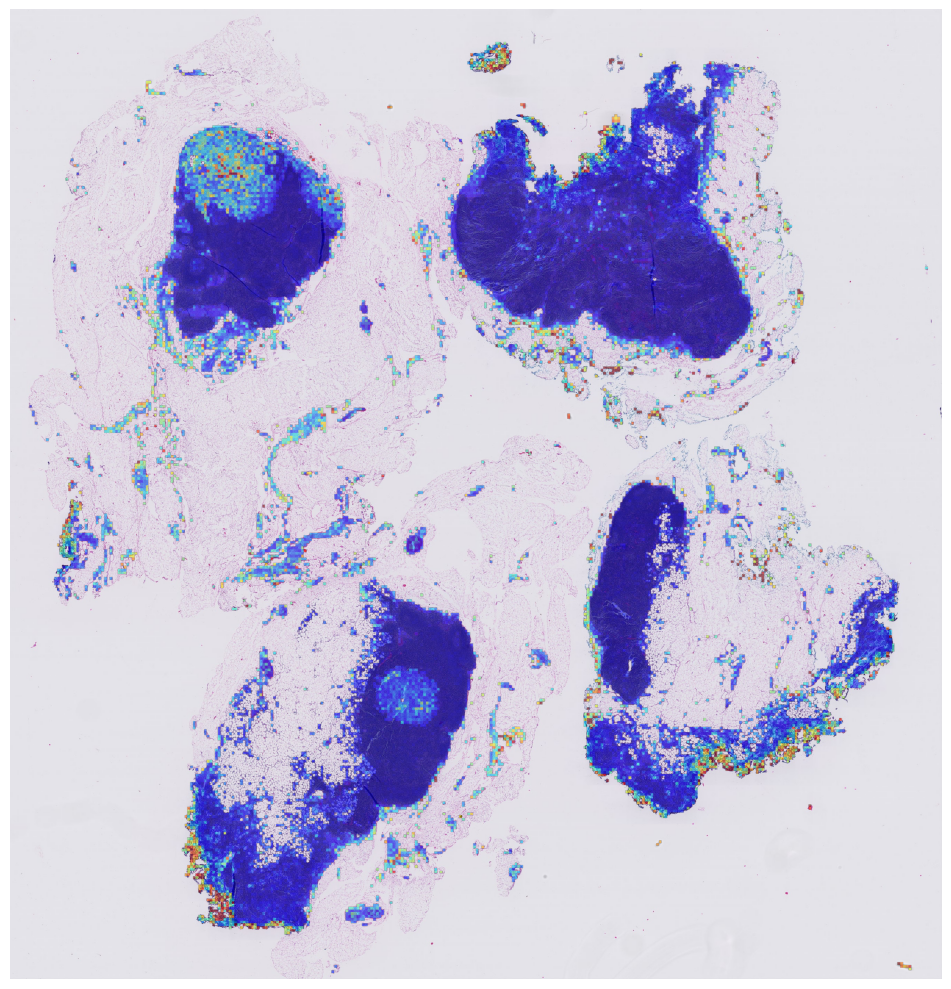

saved: /kaggle/working/test_001_anomaly_heatmap_overlay.png


In [56]:
import os
import re
import numpy as np
import pandas as pd
import openslide
import matplotlib.pyplot as plt
from PIL import Image

WSI_PATH = "/kaggle/working/test_001.tif"
CSV_PATH = "/kaggle/working/ICCV2025_Ano-NAViLa/exp/251017/patch_Ascores/test_001_Ascores.csv"
OUT_PATH = "/kaggle/working/test_001_anomaly_heatmap_overlay.png"

slide = openslide.OpenSlide(WSI_PATH)
W, H = slide.dimensions

df = pd.read_csv(CSV_PATH)
print(df.head())
print(df.shape)

def parse_xy(patch_name):
    name = os.path.basename(str(patch_name)).replace(".png", "")
    parts = name.split("_")
    x = int(parts[-3])
    y = int(parts[-2])
    return x, y

df["x"], df["y"] = zip(*df["patch_name"].map(parse_xy))

thumb = slide.get_thumbnail((2000, 2000)).convert("RGB")
thumb_arr = np.array(thumb)

scale_x = thumb_arr.shape[1] / W
scale_y = thumb_arr.shape[0] / H

heat = np.full((thumb_arr.shape[0], thumb_arr.shape[1]), np.nan, dtype=np.float32)

PATCH_SIZE = 256

for _, row in df.iterrows():
    x0 = int(row["x"] * scale_x)
    y0 = int(row["y"] * scale_y)
    x1 = int((row["x"] + PATCH_SIZE) * scale_x)
    y1 = int((row["y"] + PATCH_SIZE) * scale_y)

    heat[y0:y1, x0:x1] = float(row["Ascore"])

valid = ~np.isnan(heat)
heat_norm = np.zeros_like(heat, dtype=np.float32)

if valid.any():
    vals = heat[valid]
    lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
    heat_norm[valid] = np.clip((heat[valid] - lo) / (hi - lo + 1e-8), 0, 1)

masked_heat = np.ma.masked_where(~valid, heat_norm)

plt.figure(figsize=(10, 10))
plt.imshow(thumb_arr)
plt.imshow(masked_heat, cmap="jet", alpha=0.55)
plt.axis("off")
plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200, bbox_inches="tight", pad_inches=0)
plt.show()

print("saved:", OUT_PATH)

In [57]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/working/ICCV2025_Ano-NAViLa/exp/251017/patch_Ascores/test_001_Ascores.csv"
)

df.sort_values("Ascore", ascending=False).head(20)

,patch_name,Ascore
20040,test_001_65536_68352_0.png,0.001504
19007,test_001_18944_83712_0.png,0.001466
21370,test_001_19200_81920_0.png,0.001323
7266,test_001_58112_37120_0.png,0.001287
2732,test_001_69632_51200_0.png,0.001278
19622,test_001_55040_71168_0.png,0.001270
20943,test_001_39168_71168_0.png,0.001257
2737,test_001_66560_70144_0.png,0.001246
22656,test_001_68608_50688_0.png,0.001231
11252,test_001_52480_35328_0.png,0.001228


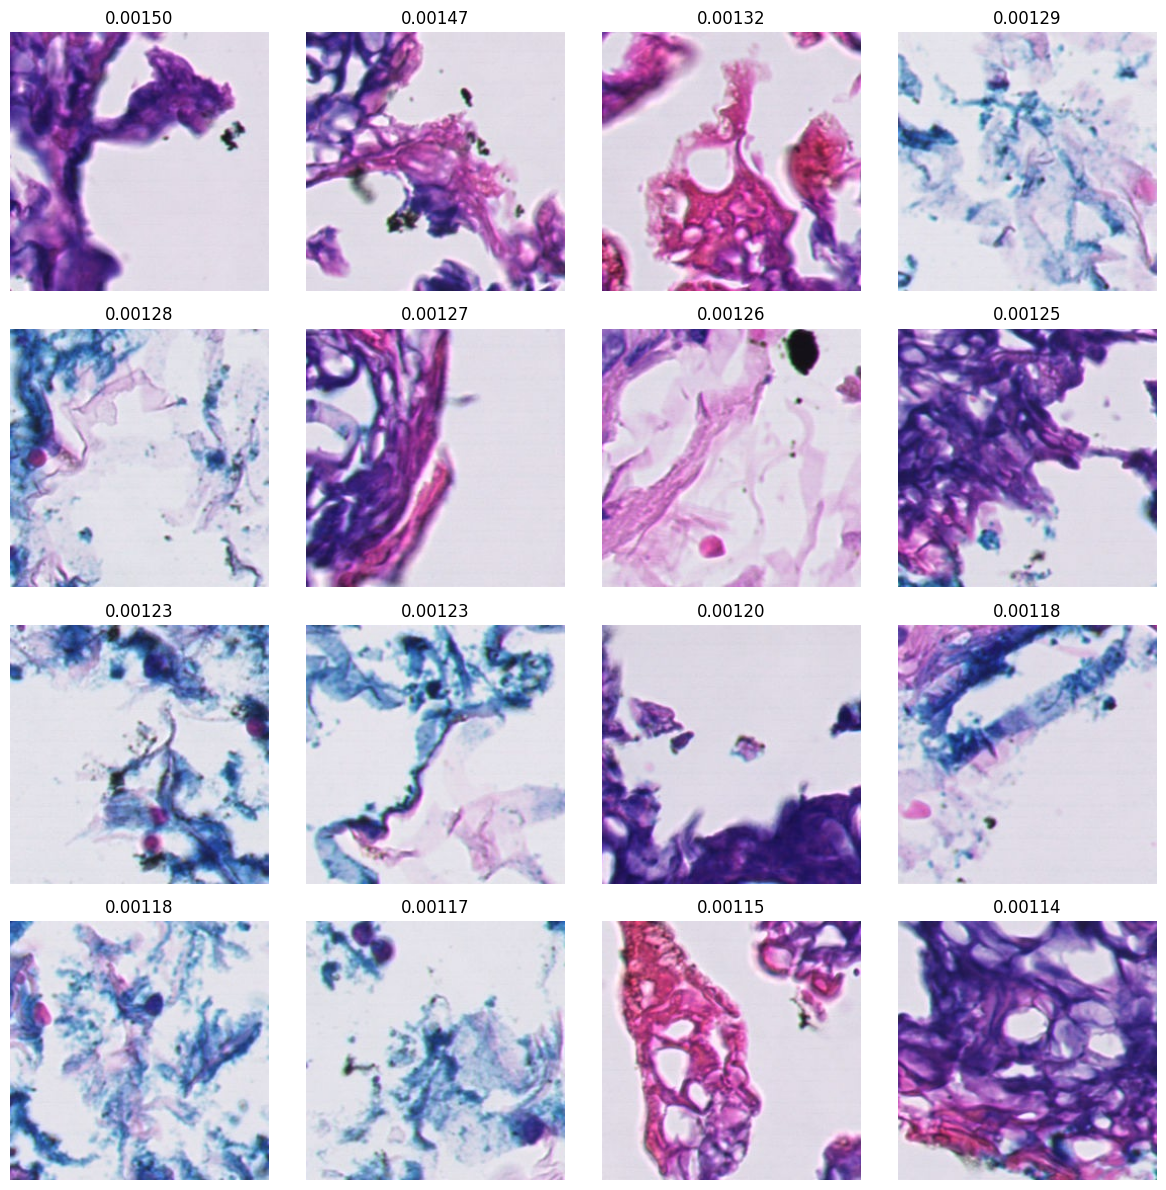

In [59]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

df = pd.read_csv(
    "/kaggle/working/ICCV2025_Ano-NAViLa/exp/251017/patch_Ascores/test_001_Ascores.csv"
)

top = df.sort_values("Ascore", ascending=False).head(16)

fig, axes = plt.subplots(4,4, figsize=(12,12))

for ax, (_, row) in zip(axes.ravel(), top.iterrows()):

    p = os.path.join(
        "/kaggle/working/test_patches/test_001",
        row["patch_name"]
    )

    img = Image.open(p)

    ax.imshow(img)
    ax.set_title(f'{row["Ascore"]:.5f}')
    ax.axis("off")

plt.tight_layout()
plt.show()

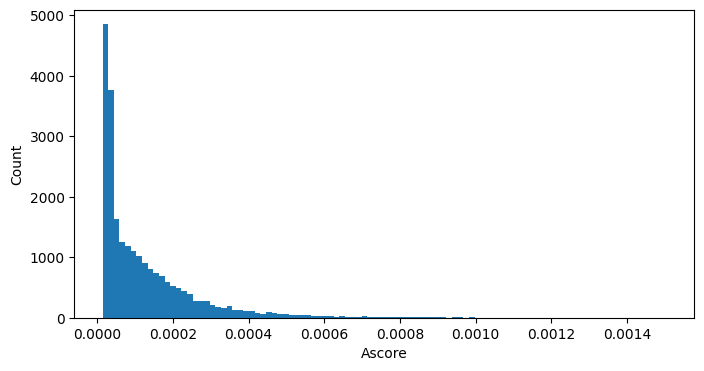

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/working/ICCV2025_Ano-NAViLa/exp/251017/patch_Ascores/test_001_Ascores.csv"
)

plt.figure(figsize=(8,4))
plt.hist(df["Ascore"], bins=100)
plt.xlabel("Ascore")
plt.ylabel("Count")
plt.show()

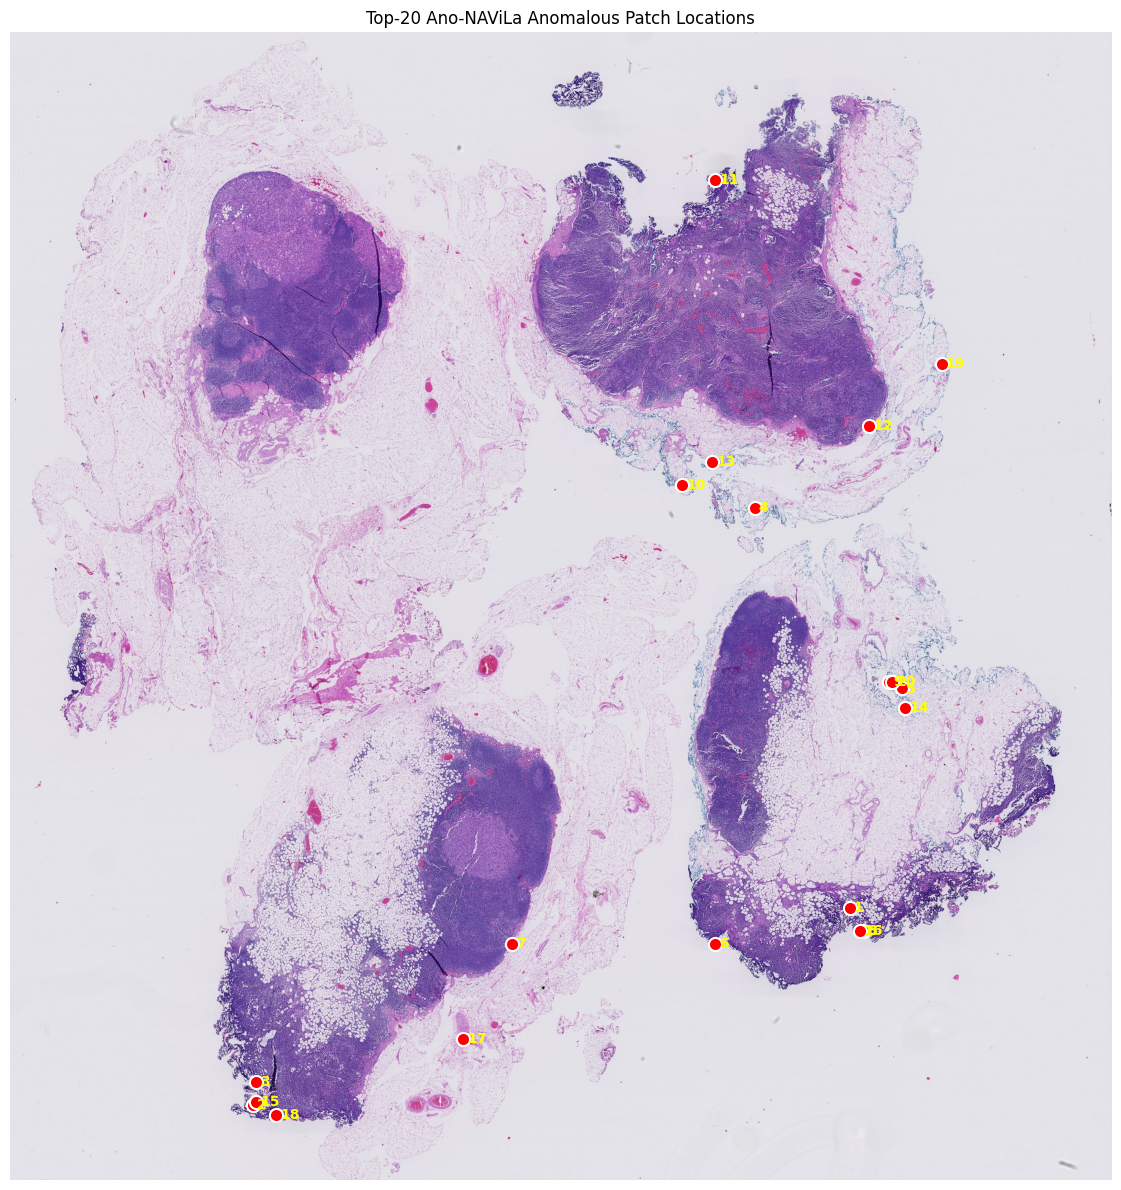

saved: /kaggle/working/test_001_top20_locations.png


,patch_name,Ascore,x,y
20040,test_001_65536_68352_0.png,0.001504,65536,68352
19007,test_001_18944_83712_0.png,0.001466,18944,83712
21370,test_001_19200_81920_0.png,0.001323,19200,81920
7266,test_001_58112_37120_0.png,0.001287,58112,37120
2732,test_001_69632_51200_0.png,0.001278,69632,51200
19622,test_001_55040_71168_0.png,0.001270,55040,71168
20943,test_001_39168_71168_0.png,0.001257,39168,71168
2737,test_001_66560_70144_0.png,0.001246,66560,70144
22656,test_001_68608_50688_0.png,0.001231,68608,50688
11252,test_001_52480_35328_0.png,0.001228,52480,35328


In [60]:
import os
import pandas as pd
import numpy as np
import openslide
import matplotlib.pyplot as plt

WSI_PATH = "/kaggle/working/test_001.tif"
CSV_PATH = "/kaggle/working/ICCV2025_Ano-NAViLa/exp/251017/patch_Ascores/test_001_Ascores.csv"
OUT_PATH = "/kaggle/working/test_001_top20_locations.png"

slide = openslide.OpenSlide(WSI_PATH)
W, H = slide.dimensions

df = pd.read_csv(CSV_PATH)

def parse_xy(patch_name):
    name = os.path.basename(str(patch_name)).replace(".png", "")
    parts = name.split("_")
    x = int(parts[-3])
    y = int(parts[-2])
    return x, y

df["x"], df["y"] = zip(*df["patch_name"].map(parse_xy))

top = df.sort_values("Ascore", ascending=False).head(20).copy()

thumb = slide.get_thumbnail((2200, 2200)).convert("RGB")
thumb_arr = np.array(thumb)

scale_x = thumb_arr.shape[1] / W
scale_y = thumb_arr.shape[0] / H

top["tx"] = top["x"] * scale_x
top["ty"] = top["y"] * scale_y

plt.figure(figsize=(12, 12))
plt.imshow(thumb_arr)

plt.scatter(
    top["tx"],
    top["ty"],
    s=90,
    c="red",
    marker="o",
    edgecolors="white",
    linewidths=1.5
)

for idx, (_, row) in enumerate(top.iterrows(), start=1):
    plt.text(
        row["tx"] + 8,
        row["ty"] + 8,
        str(idx),
        color="yellow",
        fontsize=10,
        weight="bold"
    )

plt.title("Top-20 Ano-NAViLa Anomalous Patch Locations")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200, bbox_inches="tight", pad_inches=0)
plt.show()

print("saved:", OUT_PATH)
top[["patch_name", "Ascore", "x", "y"]]